# 18_归一化方法-最大绝对值缩放

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天咱们聊聊归一化方法中非常好用的最大绝对值缩放\~

首先，**归一化**就是把数据「按比例缩放」，变成一个统一的范围，常见的是[-1, 1] 或 [0, 1]，这样不同量纲的数据就能放在一起比较，或者喂给机器学习模型时更加稳定、收敛更快。

## 什么是最大绝对值缩放？

最大绝对值缩放，就是：

> **用数据中“最远离0”的那个数（最大的绝对值）来当作基准，把所有数据“除以”这个值，这样结果就会被压缩到 [-1, 1] 之间。**

这个“最大绝对值”可以是最大正数或最小负数，只看谁离 0 更远。

### 举个例子

有一组数据：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
原始数据：[-10, -5, 0, 3, 7]
```

其中，**最大绝对值**是 10（因为 |-10| = 10 是最大的）。

我们就拿每个数除以 10：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
归一化结果：[-1.0, -0.5, 0.0, 0.3, 0.7]
```

现在所有数都被压缩到了 [-1, 1] 这个范围里。

## 最大绝对值缩放的数学原理

对于一个数据集中的某个数值 $x_i$，最大绝对值缩放的归一化公式是：


$$
x_i' = \frac{x_i}{\max(|x|)}
$$


其中：

- $x_i'$：归一化后的数据
- $x_i$：原始数据
- $\max(|x|)$：所有数据绝对值中的最大值，即：


$$
\max(|x|) = \max \left( |x_1|, |x_2|, \dots, |x_n| \right)
$$


### 推导过程

1. **目标**：我们希望所有数据 $x_i'$ 被缩放到 [-1, 1]。
2. **观察规律**：

   - 如果你除以最大值，最大值就变成 1。
   - 如果你除以最大“绝对值”，那最远离0的正数或负数就会变成 +1 或 -1。
3. **怎么做到？**

   - 用所有数据中**绝对值最大的那个数**来当作“比例基准”，让它归一化为 ±1。
   - 其它数据就会自动落在 [-1, 1] 范围内。

### 注意点：

- **不会改变数据的正负号**（负数还是负数，正数还是正数）
- **不会把数据居中到0附近**（不像 Z-score 那样把均值拉成0）
- **不适用于存在异常值的情况**（因为极端的最大值会导致其它值过小）

## 最大绝对值缩放的算法流程

### 算法流程（详细步骤）

1. **准备原始数据**：

   - 输入一组数值数据 $X = \{x_1, x_2, ..., x_n\}$
2. **计算最大绝对值**：

$M = \max\left(|x_1|, |x_2|, ..., |x_n|\right)$

- 这一步是找出离 0 最远的数（不论是正还是负）

1. **对每个数据做缩放处理**：

$x_i' = \frac{x_i}{M}, \quad \text{对于所有的 } x_i$

- 把每个数据都除以这个最大绝对值

1. **输出归一化后的数据集**：

$X' = \{x_1', x_2', ..., x_n'\}$

- 此时所有的 $x_i' \in [-1, 1]$

一句话：**最大绝对值缩放**就是，“找出最‘离谱’的那个值作为参照，把所有数据除以它”，这样所有数都被压到 [-1, 1] 的范围，正负号不变，适合处理稀疏数据（如文本、图像等）。

## 完整案例

设想你是一家电商平台的数据分析师。你正在研究客户群体的消费行为模式，目的是对用户做聚类分析（无监督学习），进而支持精准营销。

你拿到的数据包括以下特征：

- 每月浏览次数
- 每月下单次数
- 平均订单金额（单位：元）
- 商品加购数量
- 客服交互频次
- 近一年退款次数

这些特征来自不同量纲，有的偏大（如订单金额几千元），有的偏小（如加购次数只有个位数），直接使用会影响聚类模型效果。因此，你需要对数据进行归一化。

你决定采用「最大绝对值缩放」这种归一化方法，看看它是否在这类稀疏、非负、带有异常值的行为数据中更适合。

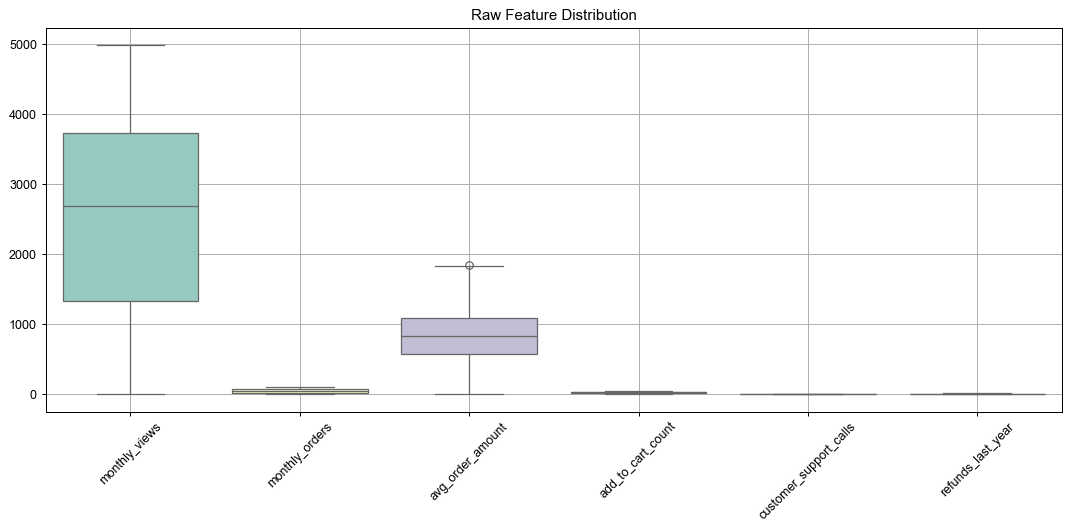

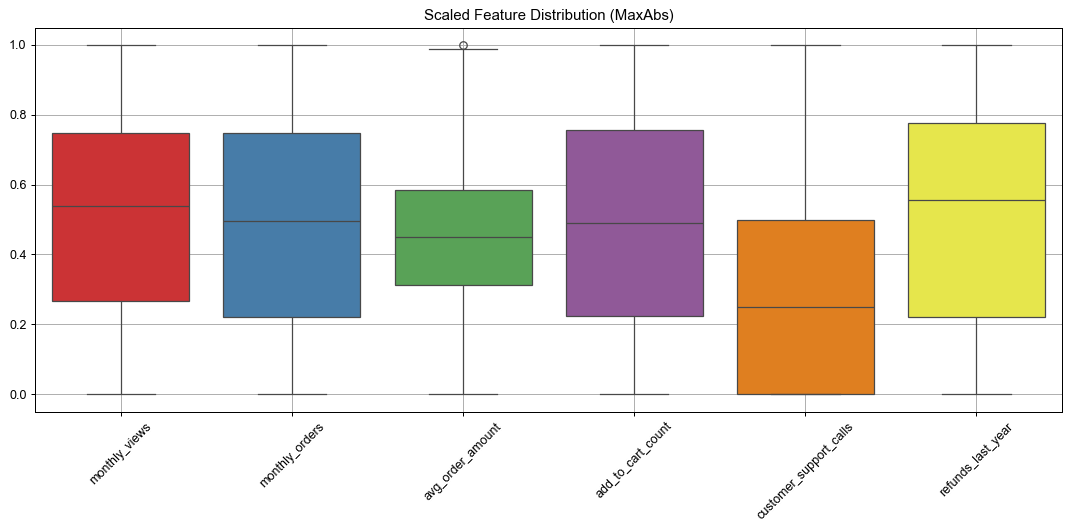

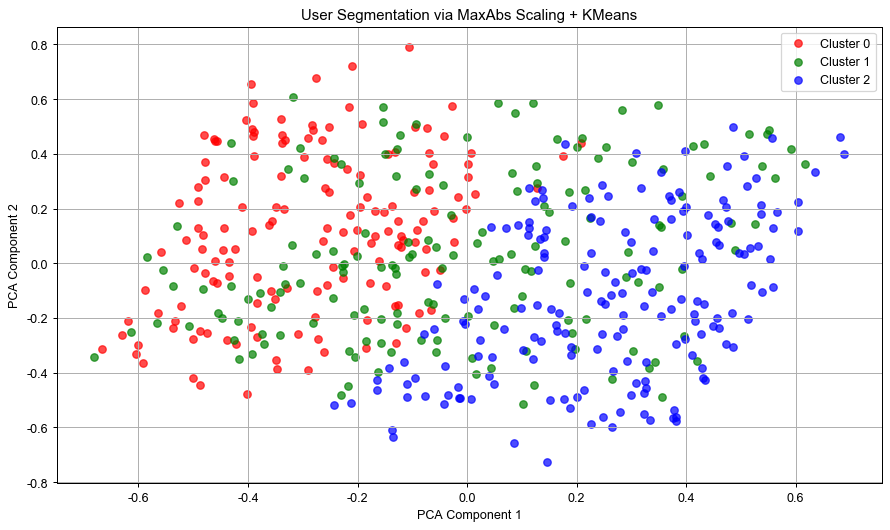

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MaxAbsScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. 生成模拟用户行为数据
np.random.seed(42)
n_samples = 500

data = {
    "monthly_views": np.random.randint(0, 5000, n_samples),
    "monthly_orders": np.random.randint(0, 100, n_samples),
    "avg_order_amount": np.random.normal(800, 400, n_samples).clip(min=0),
    "add_to_cart_count": np.random.randint(0, 50, n_samples),
    "customer_support_calls": np.random.poisson(1, n_samples),
    "refunds_last_year": np.random.randint(0, 10, n_samples),
}

df = pd.DataFrame(data)

# 2. 原始数据可视化
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, palette="Set3")
plt.title("Raw Feature Distribution")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. 应用最大绝对值缩放
scaler = MaxAbsScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# 4. 缩放后数据可视化
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_scaled, palette="Set1")
plt.title("Scaled Feature Distribution (MaxAbs)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. PCA 降维用于可视化聚类效果
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)

# 6. 使用 KMeans 聚类
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(df_scaled)

# 7. 聚类结果可视化
plt.figure(figsize=(10, 6))
colors = ['red', 'green', 'blue']
for i in range(3):
    plt.scatter(X_pca[labels == i, 0], X_pca[labels == i, 1], 
                label=f'Cluster {i}', color=colors[i], alpha=0.7)

plt.title("User Segmentation via MaxAbs Scaling + KMeans")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### 1. 数据生成部分

In [3]:
np.random.seed(42)

- 固定随机种子，保证结果可复现。

In [4]:
data = df.to_dict(orient="list")
# 上面完整案例中的六个特征，不再用省略号占位。

- 构造多种行为特征，刻画用户活跃度、消费能力、服务敏感度等维度。

#### 2. 原始数据可视化

<Axes: >

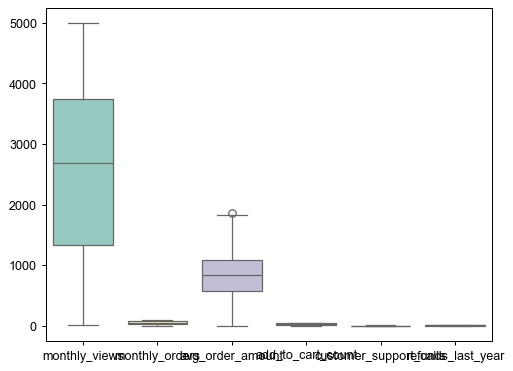

In [5]:
sns.boxplot(data=df, palette="Set3")

- 使用箱线图查看每个特征的分布、是否存在异常值（如极高的订单金额）。
- 可以清楚看到，不同特征数值分布差异极大。

![原文参考图，当前结果见代码输出](attachments/img_014.png)

#### 3. 最大绝对值缩放

In [6]:
scaler = MaxAbsScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

- 核心归一化步骤：对每列数据除以其最大绝对值，缩放到 [-1, 1] 区间（本案例中大部分数据为非负，实际范围在 [0, 1]）。

#### 4. 缩放后数据可视化

<Axes: >

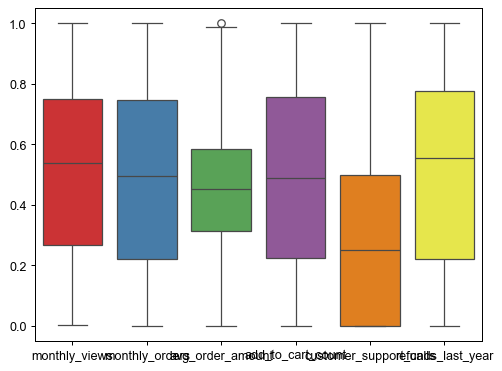

In [7]:
sns.boxplot(data=df_scaled, palette="Set1")

- 所有特征都被统一缩放，不再有大数量级差异。
- 各维度被等价对待，利于模型学习。

![原文参考图，当前结果见代码输出](attachments/img_015.png)

#### 5. PCA 降维

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)

- 将多维特征压缩成二维，便于用图表示聚类结构。

#### 6. 聚类 + 可视化

In [9]:
kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(df_scaled)

- 使用 KMeans 聚类算法对归一化后的数据分组，寻找潜在用户类型。

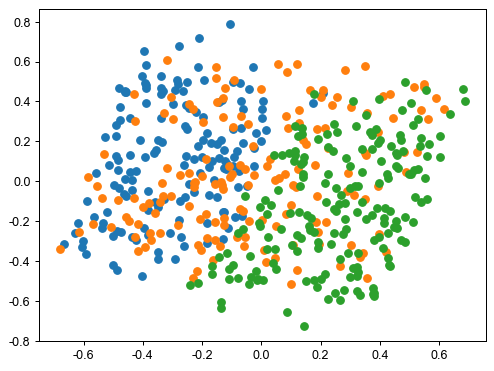

In [10]:
for i in range(3):
    plt.scatter(X_pca[labels == i, 0], X_pca[labels == i, 1])

- 通过 PCA 结果展示聚类效果，不同颜色代表不同群体。
- 若没有归一化处理，聚类会受数量级大的特征主导。

![原文参考图，当前结果见代码输出](attachments/img_016.png)

### 可视化解读与分析

- **原始数据中**，特征分布极度不均，如「平均订单金额」的数值远远大于其他特征。
- **经过最大绝对值缩放后**，所有维度都被标准压缩，使模型更公平地看待所有维度。
- **PCA 图像中出现清晰的聚类结构**，说明归一化提高了聚类的质量。
- **颜色使用红-绿-蓝强对比**，更清晰地区分不同类别。

### 使用最大绝对值缩放的优缺点

**优点**：

1. **不会改变数据的稀疏性**：非常适合文本、点击率等稀疏特征数据。
2. **计算高效、易于实现**：仅需遍历一次数据求最大绝对值，处理速度快。
3. **不改变正负符号**：特别重要于神经网络等模型中，避免信息丢失。
4. **结果稳定，不依赖分布假设**：不像 Z-score 依赖于正态分布，也不像 MinMax 受极端值强烈影响。

**缺点**：

1. **受异常值影响较大**：若最大值是一个异常极大值，会导致其他值归一化后几乎变为0。
2. **不具备居中能力**：不会让数据围绕 0 对称，不适合 PCA 这种对“居中”敏感的模型。
3. **特征之间无交互处理**：每一列独立缩放，无法发现维度之间的比例关系。
4. **归一后维度可解释性降低**：原始单位消失，特征直观意义变弱。

### 什么情况下选择 MaxAbs Scaling？

**适用场景如下：**

1. **特征稀疏且非负**（如 One-Hot 编码、文本向量、点击频次）：因为最大绝对值缩放不会压缩为负数，非常适合这类场景。
2. **不要求均值为0的算法**：如 KMeans、最近邻（KNN）、树模型（XGBoost、Random Forest），这些对数值分布不敏感。
3. **大规模数据或实时系统**：MaxAbsScaler 可在线实现，资源开销低，适合边训练边归一的模型（如线上推荐系统）。
4. **避免极端缩放**：比如订单金额过大，但我们又不想对它进行 log 处理。

**不推荐使用场景**：

- **需要数据围绕 0 分布的算法**（如 PCA、SVM、线性回归），这些模型更偏好 z-score 归一化。
- **异常值过多**：极值过大会让绝大多数数据失去辨识度。

## 总结

最大绝对值缩放是一种简单而高效的归一化技术，适用于非常广泛的实际问题，特别是：

- 大数据环境
- 非负稀疏特征
- 不敏感于均值的算法

尽管它不像 Z-score 或 MinMax 那样“强力”，但它在保证稀疏结构、符号保持的前提下，又提供了轻量级的预处理方式，是构建工业级机器学习管道不可或缺的一部分。